In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

TRAIN_DATASET_DIR = "./learn_dataset_single_object"   # 学習: 単一物体
TEST_DATASET_DIR  = "./learn_dataset_fixed_angle"      # テスト: 2物体同時
TRAIN_META_CSV = os.path.join(TRAIN_DATASET_DIR, "metadata.csv")
TEST_META_CSV  = os.path.join(TEST_DATASET_DIR,  "metadata.csv")
MODEL_PATH = "./best_detector_single_object.pt"

N_FIXED = 10

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3

D_TOL = 2
R_TOL = 3

print("DEVICE:", DEVICE)
print("TRAIN_META_CSV exists:", os.path.exists(TRAIN_META_CSV))
print("TEST_META_CSV  exists:", os.path.exists(TEST_META_CSV))


DEVICE: cpu
META_CSV exists: True


In [2]:
def Radar_setting():
    ###### symbol time & carrier frequency ######
    T_symbol = 5.575 * 1e-6              # symbol duration, with CP time
    T_OFDM = 5.2125 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545*1e-9                      # sampling time

    ###### tx/rx ######
    N_ant = 16                       # the number of antennas
    # BW = 1.966080e+9                      # chirp bandwidth
    BW = 400*1e+6                    # chirp bandwidth
    BW_sub = BW/N_ant
    N_sample = int(np.floor(T_symbol/Tc))           # the number of samples of single chirp
    rx_sample = 813 + N_sample

    ###### Radar setting ######

    mu = BW_sub/T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed/f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol,f_carrier,Tc,N_ant,BW,BW_sub,N_sample,rx_sample, mu, l_speed, lam, env

In [3]:
def physical_to_rd_indices(range_m, velocity_mps, N_trans, sym_duration, lam, Tc, range_offset=620, num_range_bins=190):
    c = 299792458.0
    vel_res = lam / (2.0 * sym_duration * N_trans)
    range_res = c * Tc / 2.0

    d_idx = int(np.round(velocity_mps / vel_res)) % N_trans
    r_idx = int(np.round(range_m / range_res - range_offset))

    valid = (0 <= d_idx < N_trans) and (0 <= r_idx < num_range_bins)
    return d_idx, r_idx, valid

In [4]:
def syntax_check(num, idx, y_value, velocity_value, x_pos):
    idx_list = np.zeros(num, dtype=np.int32)
    position, velocity = np.zeros((num, 3)), np.zeros((num, 3))
    i=0
    s = set()
    while i < num:
        # 初期値における距離間隔を保証するための処理
        if idx+10 in s or idx-10 in s or idx in s: continue
        for j in range(-20,20): s.add(idx+j)
        
        idx_list[i] = idx
        position[i] = np.array([x_pos[idx], y_value, 1])
        # v_cy[i] = np.array([np.random.rand(1)[0]*5.56, 0, 0])
        velocity[i] = np.array([velocity_value, 0, 0])
        
        i+=1
    return idx_list, position, velocity

In [5]:
def get_snapshot_data(cy_idx_target, ve_idx_target,x_pos, p_bs, tx, cy_v_value, ve_v_value, num_cy, num_ve, num_rp, sym_duration, N_trans,Tc, env):
    # Cyclistについて
    cy_idx = np.zeros(num_cy, dtype=np.int32)
    p_cy, v_cy = np.zeros((num_cy, 3)), np.zeros((num_cy, 3))
    # 範囲外アクセスを防ぐための処理
    cy_idx, p_cy, v_cy = syntax_check(num_cy, cy_idx_target, 15, cy_v_value, x_pos)
    n_cy = len(p_cy)
    
    # Vehicleについて
    ve_idx = np.zeros(num_ve, dtype=np.int32)
    p_ve, v_ve = np.zeros((num_ve, 3)), np.zeros((num_ve, 3))
    # 範囲外アクセスを防ぐための処理
    ve_idx, p_ve, v_ve = syntax_check(num_ve, ve_idx_target, 7.5, ve_v_value, x_pos)
    n_ve = len(p_ve)

    # ramppostについて
    p_rp, v_rp = np.zeros((num_rp, 3)), np.zeros((num_rp, 3))
    n_rp = len(p_rp)
    
    # csvファイルの読み込み
    cy_idx += 1
    ve_idx += 1

    P_rx_cy, tstemp_rx_cy, phase_cy, P_rx_ve, tstemp_rx_ve, phase_ve, P_rx_rp, tstemp_rx_rp, phase_rp = [], [], [], [], [], [], [], [], []
    # 3番目のデータから読み込み開始（最初の数個はノイズのみのため）
    for i in range(len(cy_idx)):
        df = pd.read_csv("./ped/2.545nano/far/complex-impulse-response-Run{:04d}-Sensor_0_Tx_0_to_Rx_0.csv".format(cy_idx[i]))
        tstemp_rx_cy.append(np.round((df["Time (s)"]/Tc)).values[3:])
        P_rx_cy.append(df["| Total Complex Impulse Response total | (W)"].values[3:])
        phase_cy.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[3:])
    for i in range(len(ve_idx)):
        df = pd.read_csv("./vehicle/2.545nano/far/complex-impulse-response-Run{:04d}-Sensor_0_Tx_0_to_Rx_0.csv".format(ve_idx[i]))
        tstemp_rx_ve.append(np.round((df["Time (s)"].values[3:]/Tc)))
        P_rx_ve.append(df["| Total Complex Impulse Response total | (W)"].values[3:])
        phase_ve.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[3:])
    # 2.545のほうを使う！
    for i in range(2,3):
        df = pd.read_csv("./Ramposts/2.545nano/"+str(i)+"/complex-impulse-response-Run0001-Sensor_0_Tx_0_to_Rx_0.csv")
        tstemp_rx_rp.append(np.round((df["Time (s)"].values[5:]/Tc)))
        P_rx_rp.append(df["| Total Complex Impulse Response total | (W)"].values[5:])
        phase_rp.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[5:])
    phys_quantities = env.phys_quantities(p_bs, p_cy, v_cy, n_cy, p_ve, v_ve, n_ve, p_rp, v_rp, n_rp)
    #print(phys_quantities["relative_velocity"]["cyclists"])
    real_cy_coordinates = []
    real_vel_coordinates = []
    real_rp_coordinates = []

    for i in range(len(p_cy)):
        real_cy_coordinates.append(np.array([p_cy[i][0], p_cy[i][1]]))
    for i in range(len(p_ve)):
        real_vel_coordinates.append(np.array([p_ve[i][0], p_ve[i][1]]))
    for i in range(len(p_rp)):
        real_rp_coordinates.append(np.array([p_rp[i][0], p_rp[i][1]]))
    
        
    ######### We need some functions here. it is like this. read the csv. this outputs the time stemp and corresponding rx value.
    # P_rx_cy_dB = -114
    #P_rx_cy_dB = -111
    #P_rx_ve_dB = -114
    #P_rx_cy_dB = 0
    #P_rx_ve_dB = 0
    
    P_N_dB = -87.98

    Y = env.rx_multiple(tx, P_rx_cy, tstemp_rx_cy, phase_cy, P_rx_ve, tstemp_rx_ve, phase_ve, P_rx_rp, tstemp_rx_rp, phase_rp, P_N_dB, sym_duration, N_trans)
    
    return Y, phys_quantities, real_cy_coordinates, real_vel_coordinates, real_rp_coordinates

In [6]:
def stevec(N_ant, angle):
    # 入力された角度に対するステアリングベクトルの計算
    resp = (np.arange(N_ant)-N_ant*0.5+0.5).reshape([-1,1])
    resp = np.exp(1j*resp*np.pi*np.sin(angle))
    return np.matrix(resp)

In [7]:
def MUSIC_method_improved(Y, N_ant, num_signals, frame_count):
    '''
    修正前
    Y_music = np.mean(Y, axis=0)
    R_yy = Y_music@np.conjugate(np.transpose(Y_music))
    '''
    # 修正後: 
    # チャープ軸(0)とサンプル軸(2)の両方を「スナップショット」として扱います。
    # (N_trans, N_ant, N_sample) -> (N_ant, N_trans * N_sample) に変形
    # これにより、N_trans(チャープ数)が増えるほど、スナップショット数が増え、
    # 共分散行列 R_yy の推定精度が向上します。
    N_trans, N_ant_data, N_sample = Y.shape
    # データを (アンテナ数 x 全サンプル数) の2次元行列に変形
    Y_music = Y.transpose(1, 0, 2).reshape(N_ant_data, -1)
    
    # 共分散行列の計算
    # (行列サイズは アンテナ数 x アンテナ数 のまま変わらないので計算負荷は軽微です)
    R_yy = (Y_music @ np.conjugate(Y_music.T)) / Y_music.shape[1]
    
    # 1.固有値分解
    eig_val, eig_vec = np.linalg.eig(R_yy)
    
    # 2.固有値をソートして雑音部分空間を取得
    idx = np.abs(eig_val).argsort()[::-1]
    # インデックスによって固有値と固有ベクトルの対応関係を維持しつつソート
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 雑音部分空間Uを取得

    # num_signalsを固有値から推定?
    
    # デバッグ用
    num_signals = 5
    
    U = eig_vec[:, num_signals:]
    

    # 3.雑音部分空間とvalごとのステアリングベクトルの内積を計算
    resp = []
    argm = (np.arange(1800)-900)/100
    for val in argm:
        # ステアリングベクトルの計算
        stv = stevec(N_ant, val*np.pi/180)
        # 雑音部分空間との内積
        p = stv.T@U
        # L2ノルムの二乗を計算(pp^H)
        pp = p*np.conjugate(np.transpose(p))
        # A1は行列を1次元配列に変換するメソッド
        # respに逆数を追加
        # 分子は角度推定の上では不要なので省略している
        resp.append(1/(np.abs(pp)**2).A1)
    
    # 4.ピーク検出
    M = np.max(resp)
    
    # デバッグ用
    #MUSIC_method_Debug(eig_val, N_ant, num_signals, resp, argm, M, frame_count)
    
    est_ang = []
    # 三点比較によるピーク検出
    a, b = resp[0][0], resp[1][0]
    for i in range(1,len(argm)-1):
        c = resp[i+1][0]
        #if a < b and b > c and b > 0.2 * M:
        if a < b and b > c and b > 0.00001 * M:
            est_ang.append(argm[i])
        a, b = b, c
    return est_ang

In [8]:
def FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, sym_duration, lam, Tc, env):
    # ドップラー処理
    Dopp_dft = dft(N_trans)/np.sqrt(N_trans)
    Y_dft = np.zeros((N_trans, N_ant, rx_sample), dtype=np.complex128)
    for i in range(N_ant):
        Y_dft[:,i,:] = Dopp_dft@Y[:,i,:]
    
    final_objects_all = []
    rd_maps = []

    P_range = np.arange(190)+620

    # FFTによる位置推定処理
    tx_arr = np.array(tx) 
    n_fft = 2**(int(rx_sample + N_sample).bit_length())
    #n_fft = 2048
    
    # 窓関数を掛けずにFFTする
    TX_F_all = fft(tx_arr, n=n_fft, axis=1) 
    Y_F_all = fft(Y_dft, n=n_fft, axis=2)
    
    for i in range(len(est_ang)):
        current_angle = est_ang[i]
        ang_rad = current_angle * np.pi / 180
        
        # ステアリングベクトル (N_ant, 1)
        s_vec = np.array(stevec(N_ant, ang_rad))
        
        # --- 周波数領域でのビームフォーミング ---
        
        # 受信信号の合成: Y_combined = sum(Y * s)
        # s_vec を (1, N_ant, 1) に変形して放送
        # Y_F_all: (N_trans, N_ant, n_fft)
        # 重み付け和をとってアンテナ次元を潰す -> (N_trans, n_fft)
        # 修正前
        w_vec = np.conjugate(s_vec).reshape(1, N_ant, 1)
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)
        # 修正後
        w_vec = s_vec.reshape(1, N_ant, 1) 
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)

        # 送信信号(レプリカ)の合成: X_combined = sum(X * s*)
        # 元の数式 g = s* s^H X より、Xにかかる重みは s^H (つまり sの共役)
        # TX_F_all: (N_ant, n_fft)
        s_vec_conj_reshape = np.conjugate(s_vec).reshape(N_ant, 1)
        TX_F_combined = np.sum(TX_F_all * s_vec_conj_reshape, axis=0) # -> (n_fft,)

        # --- 相関演算 (Correlation) ---
        # Correlation = IFFT( FFT(Y) * conj(FFT(X)) )
        # Broadcasting: (N_trans, n_fft) * (n_fft,)
        CORR_f = Y_F_combined * np.conjugate(TX_F_combined)
        
        # 時間領域に戻す
        corr_time = ifft(CORR_f, axis=1)

        # --- 必要な範囲を切り出し ---
        rdresp_single = corr_time[:, P_range]

        # --- 結果保存 ---
        rd_maps.append(rdresp_single.copy())
        rd_maps.append(i)

    return rd_maps

In [9]:
def generate_one_sample(sample_id, target_idx):
    T_symbol, f_carrier, Tc, N_ant, BW, BW_sub, N_sample, rx_sample, mu, l_speed, lam, env = Radar_setting()
    N_chirp = 89
    N_trans = N_chirp
    tx = env.tx()

    p_bs = np.array([250, -18, 50])
    x_pos = list(np.arange(-450, -149) / 10)

    if TARGET_KIND == "ped":
        num_cy, num_ve, num_rp = 1, 0, 0
        cy_idx_target = int(target_idx)
        ve_idx_target = 128
        cy_v_value, ve_v_value = 6, 10
        target_label = 0
    else:
        num_cy, num_ve, num_rp = 0, 1, 0
        cy_idx_target = 150
        ve_idx_target = int(target_idx)
        cy_v_value, ve_v_value = 6, 10
        target_label = 1

    Y, phys_quantities, real_cy_coordinates, real_vel_coordinates, real_rp_coordinates = get_snapshot_data(
        cy_idx_target, ve_idx_target, x_pos, p_bs, tx,
        cy_v_value, ve_v_value, num_cy, num_ve, num_rp,
        T_symbol, N_trans, Tc, env
    )

    est_ang = MUSIC_method_improved(Y, N_ant, num_cy + num_ve + num_rp, frame_count=sample_id)
    rd_maps = FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, T_symbol, lam, Tc, env)

    target_kinds = []
    target_labels = []
    true_ranges = []
    true_velocities = []
    true_angle_degs = []
    true_d_idx_list = []
    true_r_idx_list = []
    valid_list = []

    for truth_key, kind_name, label_value in [("cyclists", "ped", 0), ("vehicles", "vehicle", 1)]:
        ranges = np.asarray(phys_quantities["range"][truth_key]).reshape(-1)
        velocities = np.asarray(phys_quantities["relative_velocity"][truth_key]).reshape(-1)
        angles_rad = np.asarray(phys_quantities["angle"][truth_key]).reshape(-1)

        n_obj = min(len(ranges), len(velocities), len(angles_rad))
        for i in range(n_obj):
            range_i = float(ranges[i])
            velocity_i = float(velocities[i])
            angle_deg_i = float(np.degrees(angles_rad[i]))
            d_idx_i, r_idx_i, valid_i = physical_to_rd_indices(
                range_i, velocity_i, N_trans, T_symbol, lam, Tc
            )

            target_kinds.append(kind_name)
            target_labels.append(int(label_value))
            true_ranges.append(range_i)
            true_velocities.append(velocity_i)
            true_angle_degs.append(angle_deg_i)
            true_d_idx_list.append(int(d_idx_i))
            true_r_idx_list.append(int(r_idx_i))
            valid_list.append(int(valid_i))

    if len(target_kinds) == 0:
        raise RuntimeError("No targets found in phys_quantities. Check scenario settings.")

    primary_idx = 0
    for i, kind_name in enumerate(target_kinds):
        if kind_name == TARGET_KIND:
            primary_idx = i
            break

    true_range = true_ranges[primary_idx]
    true_velocity = true_velocities[primary_idx]
    true_angle_deg = true_angle_degs[primary_idx]
    d_idx = true_d_idx_list[primary_idx]
    r_idx = true_r_idx_list[primary_idx]
    valid = valid_list[primary_idx]

    save_path = os.path.join(OUTPUT_DIR, f"sample_{sample_id:05d}.npz")
    np.savez_compressed(
        save_path,
        rd_maps=np.array(rd_maps[::2], dtype=np.complex64),
        est_ang=np.array(est_ang, dtype=np.float32),
        true_range=np.float32(true_range),
        true_velocity=np.float32(true_velocity),
        true_angle_deg=np.float32(true_angle_deg),
        true_d_idx=np.int32(d_idx),
        true_r_idx=np.int32(r_idx),
        true_range_list=np.array(true_ranges, dtype=np.float32),
        true_velocity_list=np.array(true_velocities, dtype=np.float32),
        true_angle_deg_list=np.array(true_angle_degs, dtype=np.float32),
        true_d_idx_list=np.array(true_d_idx_list, dtype=np.int32),
        true_r_idx_list=np.array(true_r_idx_list, dtype=np.int32),
        target_labels=np.array(target_labels, dtype=np.int32),
        valid=np.int32(valid),
        valid_list=np.array(valid_list, dtype=np.int32),
        target_label=np.int32(target_label),
        source_index=np.int32(target_idx),
    )

    return {
        "sample_id": sample_id,
        "file": save_path,
        "target_kind": TARGET_KIND,
        "source_index": target_idx,
        "num_angles": len(est_ang),
        "true_range": true_range,
        "true_velocity": true_velocity,
        "true_angle_deg": true_angle_deg,
        "true_d_idx": d_idx,
        "true_r_idx": r_idx,
        "valid": int(valid),
        "num_targets": int(len(target_kinds)),
        "target_kinds_json": json.dumps(target_kinds, ensure_ascii=False),
        "target_labels_json": json.dumps(target_labels),
        "true_range_list_json": json.dumps(true_ranges),
        "true_velocity_list_json": json.dumps(true_velocities),
        "true_angle_deg_list_json": json.dumps(true_angle_degs),
        "true_d_idx_list_json": json.dumps(true_d_idx_list),
        "true_r_idx_list_json": json.dumps(true_r_idx_list),
        "valid_list_json": json.dumps(valid_list),
    }

In [10]:
class MultiTargetDataset(Dataset):
    def __init__(self, meta_df):
        self.meta_df = meta_df.reset_index(drop=True)

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        npz_path = row['file']
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join('.', npz_path))

        x = load_all_rd_maps(npz_path)  # (N_FIXED, H, W)
        H, W = x.shape[1], x.shape[2]

        valid_cy = 1 if str(row['valid_cyclist']).strip() in ('1', 'True') else 0
        valid_ve = 1 if str(row['valid_vehicle']).strip() in ('1', 'True') else 0

        # 存在するターゲットはガウスヒートマップ、不在は全ゼロ
        if valid_cy:
            y_cy = make_gaussian_heatmap(H, W, int(row['cyclist_true_d_idx']), int(row['cyclist_true_r_idx']))
        else:
            y_cy = np.zeros((H, W), dtype=np.float32)

        if valid_ve:
            y_ve = make_gaussian_heatmap(H, W, int(row['vehicle_true_d_idx']), int(row['vehicle_true_r_idx']))
        else:
            y_ve = np.zeros((H, W), dtype=np.float32)

        y = np.stack([y_cy, y_ve], axis=0)  # (2, H, W)

        return {
            'x': torch.from_numpy(x).float(),
            'y': torch.from_numpy(y).float(),
            'cy_true_d': torch.tensor(int(row['cyclist_true_d_idx']), dtype=torch.long),
            'cy_true_r': torch.tensor(int(row['cyclist_true_r_idx']), dtype=torch.long),
            've_true_d': torch.tensor(int(row['vehicle_true_d_idx']), dtype=torch.long),
            've_true_r': torch.tensor(int(row['vehicle_true_r_idx']), dtype=torch.long),
            'valid_cy': torch.tensor(valid_cy, dtype=torch.long),
            'valid_ve': torch.tensor(valid_ve, dtype=torch.long),
        }


In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)

class RadarLightUNet(nn.Module):
    def __init__(self, in_channels=N_FIXED, out_channels=2, fixed_channels=32, dropout=0.1):
        super().__init__()

        self.encoders = nn.ModuleList([
            ConvBlock(in_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
        ])
        self.pools = nn.ModuleList([
            nn.MaxPool2d(2, 2) for _ in range(4)
        ])
        self.bottleneck = ConvBlock(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        self.head = nn.Conv2d(fixed_channels, out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.head(x)  # logits (B, 2, H, W)

In [12]:
# 学習用: 単一物体データセット
train_all_df = pd.read_csv(TRAIN_META_CSV)
train_all_df = train_all_df[train_all_df['valid_all'] == 1].reset_index(drop=True)

n = len(train_all_df)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

train_df = train_all_df.iloc[:n_train].reset_index(drop=True)
val_df   = train_all_df.iloc[n_train:n_train+n_val].reset_index(drop=True)

# テスト用: 2物体同時データセット
test_df = pd.read_csv(TEST_META_CSV)
test_df = test_df[test_df['valid_all'] == 1].reset_index(drop=True)

print('train:', len(train_df), '  val:', len(val_df), '  test:', len(test_df))
display(train_df.head())


all  : 300
train: 205
val  : 15
test : 80


,sample_id,file,source_index_cyclist,source_index_vehicle,cyclist_true_range,cyclist_true_velocity,cyclist_true_angle_deg,cyclist_true_d_idx,cyclist_true_r_idx,vehicle_true_range,vehicle_true_velocity,vehicle_true_angle_deg,vehicle_true_d_idx,vehicle_true_r_idx,valid_cyclist,valid_vehicle,valid_all
0,0,./learn_dataset_fixed_angle\sample_00000.npz,1,262,300.759056,5.883115,2.838632,1,168,274.417000,9.795312,1.872870,1,99,1,1,1
1,1,./learn_dataset_fixed_angle\sample_00001.npz,2,294,300.661005,5.883038,2.840780,1,168,271.283265,9.790504,1.937766,1,91,1,1,1
2,2,./learn_dataset_fixed_angle\sample_00002.npz,3,62,300.562955,5.882961,2.842929,1,168,294.035185,9.821954,1.499588,1,151,1,1,1
3,3,./learn_dataset_fixed_angle\sample_00003.npz,4,254,300.464906,5.882883,2.845080,1,168,275.200672,9.796488,1.856885,1,101,1,1,1
4,4,./learn_dataset_fixed_angle\sample_00004.npz,5,167,300.366859,5.882806,2.847232,1,167,283.728990,9.808656,1.688927,1,124,1,1,1


In [13]:
def evaluate_split(model, meta_df, batch_size=BATCH_SIZE, device=DEVICE):
    ds = SingleTargetDataset(meta_df.reset_index(drop=True))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    loss, hit = run_epoch(model, loader, optimizer=None, device=device)
    return {
        "count": len(meta_df),
        "loss": loss,
        "hit_rate": hit,
    }

def evaluate_per_kind(model, meta_df, device=DEVICE):
    rows = []

    rows.append({
        "target_kind": "all",
        **evaluate_split(model, meta_df, device=device)
    })

    for target_kind in ["ped", "vehicle"]:
        sub_df = meta_df[meta_df["target_kind"] == target_kind].reset_index(drop=True)
        if len(sub_df) == 0:
            continue

        rows.append({
            "target_kind": target_kind,
            **evaluate_split(model, sub_df, device=device)
        })

    return pd.DataFrame(rows)

In [14]:
def make_gaussian_heatmap(H, W, center_d, center_r, sigma_d=1.5, sigma_r=2.0):
    d = np.arange(H, dtype=np.float32)[:, None]
    r = np.arange(W, dtype=np.float32)[None, :]
    heatmap = np.exp(
        -0.5 * (((d - center_d) / sigma_d) ** 2 + ((r - center_r) / sigma_r) ** 2)
    )
    return heatmap.astype(np.float32)

def load_all_rd_maps(npz_path):
    """全固定角度のRDマップを読み込んでdB正規化し (N_FIXED, H, W) で返す"""
    data = np.load(npz_path)
    rd_maps = data["rd_maps"]  # (N_FIXED, H, W) complex
    result = []
    for i in range(rd_maps.shape[0]):
        rd_mag = np.abs(rd_maps[i]).astype(np.float32)
        rd_db = 20.0 * np.log10(np.maximum(rd_mag, 1e-12))
        rd_db = (rd_db - rd_db.mean()) / (rd_db.std() + 1e-6)
        result.append(rd_db)
    return np.stack(result, axis=0)  # (N_FIXED, H, W)

def decode_peaks_from_logits(logits):
    """各チャンネルでargmaxを取り [(cy_d, cy_r, cy_conf), (ve_d, ve_r, ve_conf)] を返す"""
    probs = torch.sigmoid(logits)[0]  # (2, H, W)
    H, W = probs.shape[1], probs.shape[2]
    results = []
    for ch in range(probs.shape[0]):
        prob = probs[ch]
        flat_idx = torch.argmax(prob).item()
        d_idx = flat_idx // W
        r_idx = flat_idx % W
        conf = float(prob[d_idx, r_idx].item())
        results.append((d_idx, r_idx, conf))
    return results

def compute_hit(pred_d, pred_r, true_d, true_r, d_tol=D_TOL, r_tol=R_TOL):
    return (abs(pred_d - true_d) <= d_tol) and (abs(pred_r - true_r) <= r_tol)

In [15]:
def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    return (1 - num / den).mean()

def compute_loss(logits, targets, pos_weight=20.0):
    bce = F.binary_cross_entropy_with_logits(
        logits, targets,
        pos_weight=torch.tensor(pos_weight, device=logits.device)
    )
    dice = dice_loss_from_logits(logits, targets)
    return bce + dice

def run_epoch(model, loader, optimizer=None, device='cpu'):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    cy_hits, cy_total = 0, 0
    ve_hits, ve_total = 0, 0

    for batch in loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        cy_true_d = batch['cy_true_d'].cpu().numpy()
        cy_true_r = batch['cy_true_r'].cpu().numpy()
        ve_true_d = batch['ve_true_d'].cpu().numpy()
        ve_true_r = batch['ve_true_r'].cpu().numpy()
        valid_cy  = batch['valid_cy'].cpu().numpy()
        valid_ve  = batch['valid_ve'].cpu().numpy()

        if train_mode:
            optimizer.zero_grad()

        logits = model(x)  # (B, 2, H, W)
        loss = compute_loss(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

        for i in range(x.size(0)):
            peaks = decode_peaks_from_logits(logits[i:i+1].detach().cpu())
            cy_d, cy_r, _ = peaks[0]
            ve_d, ve_r, _ = peaks[1]
            # 存在するターゲットのみhit集計
            if valid_cy[i]:
                cy_hits  += int(compute_hit(cy_d, cy_r, int(cy_true_d[i]), int(cy_true_r[i])))
                cy_total += 1
            if valid_ve[i]:
                ve_hits  += int(compute_hit(ve_d, ve_r, int(ve_true_d[i]), int(ve_true_r[i])))
                ve_total += 1

    n = len(loader.dataset)
    mean_loss    = total_loss / max(n, 1)
    cy_hit_rate  = cy_hits / max(cy_total, 1)
    ve_hit_rate  = ve_hits / max(ve_total, 1)
    return mean_loss, cy_hit_rate, ve_hit_rate


In [16]:
train_ds = MultiTargetDataset(train_df)
val_ds   = MultiTargetDataset(val_df)
test_ds  = MultiTargetDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model = RadarLightUNet(in_channels=N_FIXED, out_channels=2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float("inf")
history = []

for epoch in range(EPOCHS):
    train_loss, train_cy_hit, train_ve_hit = run_epoch(model, train_loader, optimizer=optimizer, device=DEVICE)
    val_loss,   val_cy_hit,   val_ve_hit   = run_epoch(model, val_loader,   optimizer=None,      device=DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_cy_hit": train_cy_hit,
        "train_ve_hit": train_ve_hit,
        "val_loss": val_loss,
        "val_cy_hit": val_cy_hit,
        "val_ve_hit": val_ve_hit,
    })

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"epoch={epoch+1:02d} "
        f"train_loss={train_loss:.4f} cy={train_cy_hit:.3f} ve={train_ve_hit:.3f} | "
        f"val_loss={val_loss:.4f}   cy={val_cy_hit:.3f} ve={val_ve_hit:.3f}"
    )

print("best model saved to:", MODEL_PATH)
hist_df = pd.DataFrame(history)
display(hist_df.tail())

epoch=01 train_loss=1.4136 cy=0.073 ve=0.010 | val_loss=1.0901   cy=0.000 ve=0.000
epoch=02 train_loss=0.9815 cy=0.146 ve=0.244 | val_loss=0.9062   cy=0.200 ve=0.867
epoch=03 train_loss=0.8749 cy=0.395 ve=0.615 | val_loss=0.8126   cy=0.200 ve=1.000
epoch=04 train_loss=0.8198 cy=0.429 ve=0.580 | val_loss=0.7675   cy=0.333 ve=0.200
epoch=05 train_loss=0.7942 cy=0.361 ve=0.546 | val_loss=0.7301   cy=0.733 ve=0.533
epoch=06 train_loss=0.7356 cy=0.415 ve=0.395 | val_loss=0.6762   cy=0.600 ve=0.400
epoch=07 train_loss=0.6708 cy=0.746 ve=0.580 | val_loss=0.6151   cy=1.000 ve=0.667
epoch=08 train_loss=0.6258 cy=0.883 ve=0.654 | val_loss=0.5678   cy=1.000 ve=1.000
epoch=09 train_loss=0.5735 cy=0.961 ve=0.883 | val_loss=0.4948   cy=1.000 ve=1.000
epoch=10 train_loss=0.5059 cy=0.985 ve=0.980 | val_loss=0.4259   cy=1.000 ve=1.000
epoch=11 train_loss=0.4511 cy=0.990 ve=0.990 | val_loss=0.4184   cy=1.000 ve=0.933
epoch=12 train_loss=0.4279 cy=1.000 ve=0.995 | val_loss=0.4024   cy=1.000 ve=1.000
epoc

,epoch,train_loss,train_cy_hit,train_ve_hit,val_loss,val_cy_hit,val_ve_hit
15,16,0.396882,1.0,1.000000,0.381641,1.0,1.0
16,17,0.394592,1.0,0.995122,0.381995,1.0,1.0
17,18,0.387617,1.0,1.000000,0.384600,1.0,1.0
18,19,0.395204,1.0,1.000000,0.380097,1.0,1.0
19,20,0.387802,1.0,1.000000,0.380427,1.0,1.0


In [20]:
best_model = RadarLightUNet(in_channels=N_FIXED, out_channels=2).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_cy_hit, test_ve_hit = run_epoch(best_model, test_loader, optimizer=None, device=DEVICE)
print(f"test_loss={test_loss:.4f}  cyclist_hit={test_cy_hit:.3f}  vehicle_hit={test_ve_hit:.3f}")

test_loss=0.3793  cyclist_hit=1.000  vehicle_hit=0.988


file: ./learn_dataset_fixed_angle\sample_00220.npz
cyclist  true=(1,112) pred=(1,112) hit=True
vehicle  true=(1,130) pred=(1,130) hit=True


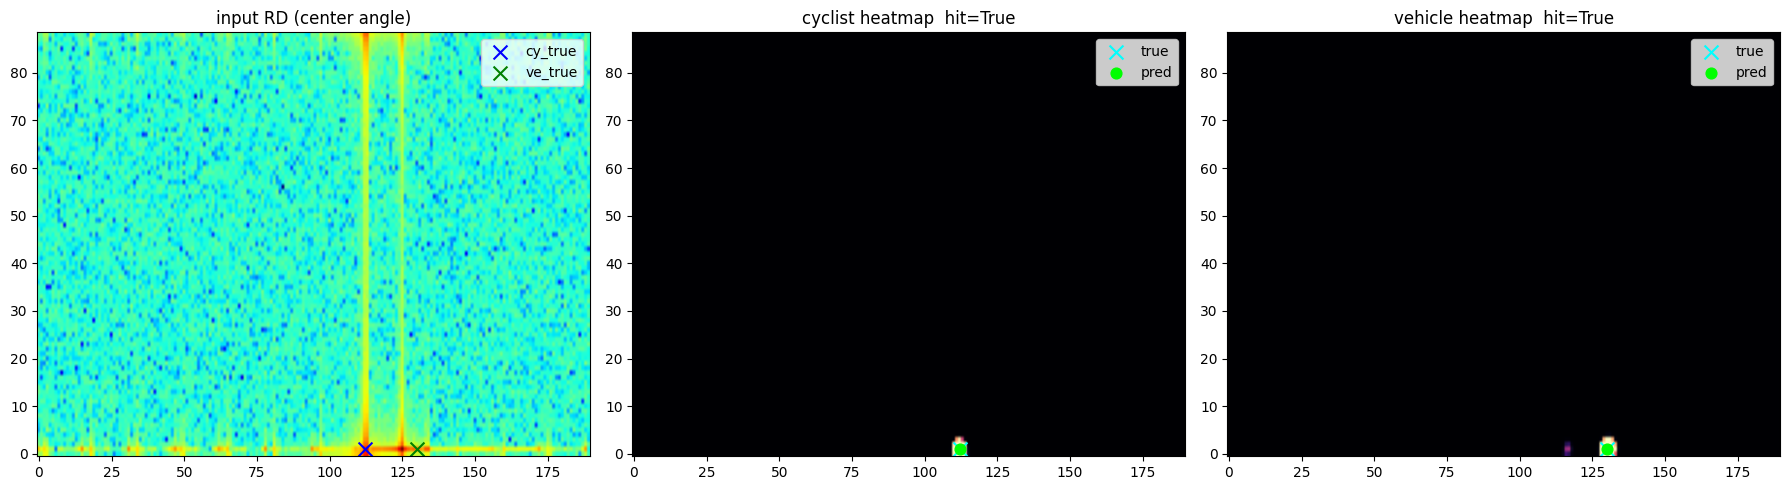

file: ./learn_dataset_fixed_angle\sample_00221.npz
cyclist  true=(1,112) pred=(1,112) hit=True
vehicle  true=(1,138) pred=(1,138) hit=True


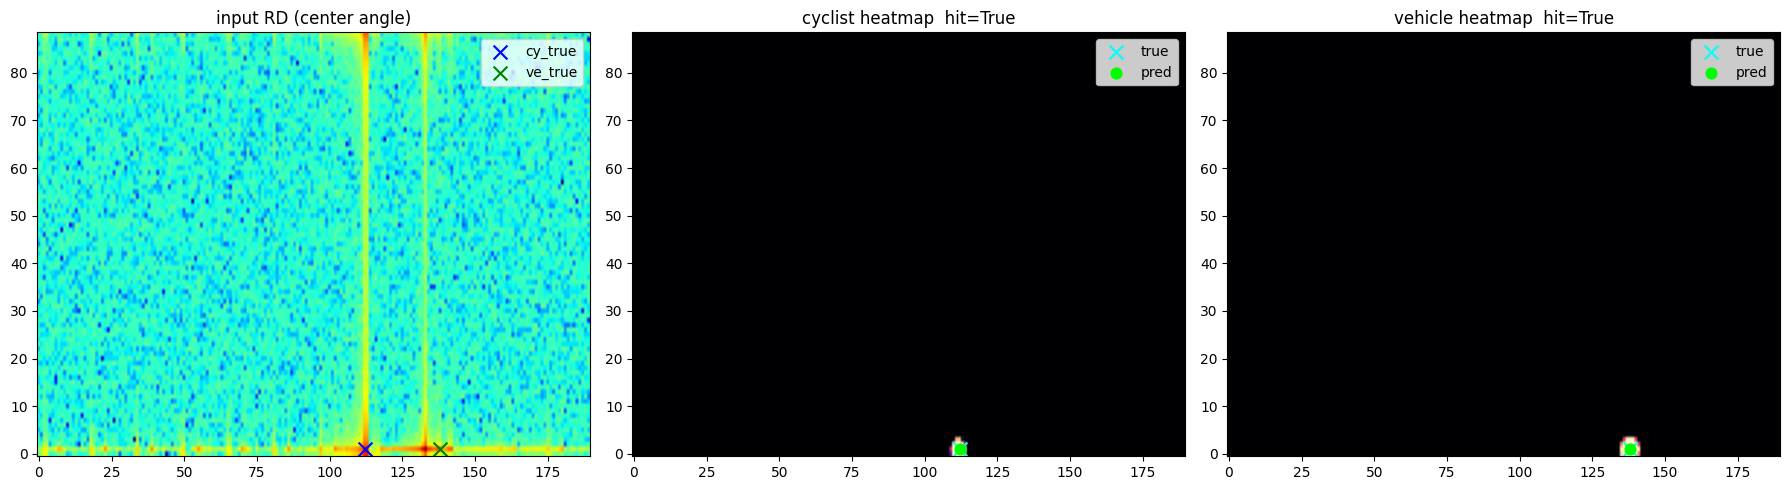

In [21]:
def show_prediction(sample_idx=0):
    row = test_df.iloc[sample_idx]
    npz_path = row['file']
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join('.', npz_path))

    x = load_all_rd_maps(npz_path)  # (N_FIXED, H, W)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    peaks = decode_peaks_from_logits(logits.cpu())
    cy_d, cy_r, cy_conf = peaks[0]
    ve_d, ve_r, ve_conf = peaks[1]

    cy_true_d = int(row['cyclist_true_d_idx'])
    cy_true_r = int(row['cyclist_true_r_idx'])
    ve_true_d = int(row['vehicle_true_d_idx'])
    ve_true_r = int(row['vehicle_true_r_idx'])

    cy_hit = compute_hit(cy_d, cy_r, cy_true_d, cy_true_r)
    ve_hit = compute_hit(ve_d, ve_r, ve_true_d, ve_true_r)

    print(f"file: {row['file']}")
    print(f"cyclist  true=({cy_true_d},{cy_true_r}) pred=({cy_d},{cy_r}) hit={cy_hit}")
    print(f"vehicle  true=({ve_true_d},{ve_true_r}) pred=({ve_d},{ve_r}) hit={ve_hit}")

    # 代表チャンネル: 中央の角度 (index=N_FIXED//2)
    rd_db = x[N_FIXED // 2]
    cy_heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()
    ve_heatmap = torch.sigmoid(logits)[0, 1].cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(rd_db, aspect='auto', origin='lower', cmap='jet')
    axes[0].scatter([cy_true_r], [cy_true_d], c='blue',  marker='x', s=100, label='cy_true')
    axes[0].scatter([ve_true_r], [ve_true_d], c='green', marker='x', s=100, label='ve_true')
    axes[0].set_title('input RD (center angle)')
    axes[0].legend()

    axes[1].imshow(cy_heatmap, aspect='auto', origin='lower', cmap='magma')
    axes[1].scatter([cy_true_r], [cy_true_d], c='cyan', marker='x', s=100, label='true')
    axes[1].scatter([cy_r],      [cy_d],      c='lime', marker='o', s=60,  label='pred')
    axes[1].set_title(f'cyclist heatmap  hit={cy_hit}')
    axes[1].legend()

    axes[2].imshow(ve_heatmap, aspect='auto', origin='lower', cmap='magma')
    axes[2].scatter([ve_true_r], [ve_true_d], c='cyan', marker='x', s=100, label='true')
    axes[2].scatter([ve_r],      [ve_d],      c='lime', marker='o', s=60,  label='pred')
    axes[2].set_title(f'vehicle heatmap  hit={ve_hit}')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

show_prediction(sample_idx=0)
show_prediction(sample_idx=1)


In [22]:
# (旧セル - e50f149aに統合済みのため空)
pass


In [23]:
def collect_predictions(meta_df):
    rows = []
    for i in range(len(meta_df)):
        row = meta_df.iloc[i]
        npz_path = row['file']
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join('.', npz_path))
        x = load_all_rd_maps(npz_path)
        x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
        with torch.no_grad():
            logits = best_model(x_tensor)
        peaks = decode_peaks_from_logits(logits.cpu())
        cy_d, cy_r, cy_conf = peaks[0]
        ve_d, ve_r, ve_conf = peaks[1]
        cy_true_d = int(row['cyclist_true_d_idx'])
        cy_true_r = int(row['cyclist_true_r_idx'])
        ve_true_d = int(row['vehicle_true_d_idx'])
        ve_true_r = int(row['vehicle_true_r_idx'])
        rows.append({
            'sample_idx': i,
            'file': row['file'],
            'cy_true_d': cy_true_d, 'cy_true_r': cy_true_r,
            'cy_pred_d': cy_d,      'cy_pred_r': cy_r,
            'cy_d_err': cy_d - cy_true_d, 'cy_r_err': cy_r - cy_true_r,
            'cy_conf': cy_conf,
            'cy_hit': compute_hit(cy_d, cy_r, cy_true_d, cy_true_r),
            've_true_d': ve_true_d, 've_true_r': ve_true_r,
            've_pred_d': ve_d,      've_pred_r': ve_r,
            've_d_err': ve_d - ve_true_d, 've_r_err': ve_r - ve_true_r,
            've_conf': ve_conf,
            've_hit': compute_hit(ve_d, ve_r, ve_true_d, ve_true_r),
        })
    return pd.DataFrame(rows)


In [ ]:
pred_df = collect_predictions(test_df)

print('=== hit rate ===')
print(f"cyclist : {pred_df['cy_hit'].mean():.3f}")
print(f"vehicle : {pred_df['ve_hit'].mean():.3f}")

print('=== cyclist 失敗例 ===')
display(pred_df[pred_df['cy_hit'] == False][['cy_true_d','cy_true_r','cy_pred_d','cy_pred_r','cy_conf']].head())
print('=== vehicle 失敗例 ===')
display(pred_df[pred_df['ve_hit'] == False][['ve_true_d','ve_true_r','ve_pred_d','ve_pred_r','ve_conf']].head())


SyntaxError: unterminated string literal (detected at line 7) (1773415687.py, line 7)

In [ ]:
print('=== 誤差統計 ===')
display(pred_df[['cy_d_err','cy_r_err','ve_d_err','ve_r_err']].agg(['mean','std','max','min']))
